# Optimization Project 3 — Non-Linear Programming (Newsvendor Model)

Pricing and production decisions for a publishing company, solved as a sequence of
optimization models in Gurobi.

**Cost structure (the firm's true operating environment):** regular production cost
`c = 0.50`, rush-order cost `g = 0.75` per unit short, disposal cost `t = 0.15` per
unit of excess. Because rush orders fill any shortfall, all demand is met, so revenue
is always `p * D`.

Run top to bottom. Requires `pandas numpy scikit-learn matplotlib gurobipy`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.linear_model import LinearRegression
import gurobipy as gp
from gurobipy import GRB

# Cost parameters
c = 0.50   # regular production cost per unit
g = 0.75   # rush-order cost per unit (g > c)
t = 0.15   # disposal cost per unit of excess

## Part 1: Linear Regression of Demand on Price

Data shape: (99, 2)
   price  demand
0   1.05     283
1   0.86     771
2   1.21     185
3   0.94     531
4   0.76    1002

beta_0 (intercept): 1924.7175
beta_1 (slope):     -1367.7125
Demand = 1924.7175 + (-1367.7125) * Price

Residuals -> mean: -0.000000, std: 149.4520, range: [-346.91, 341.42]


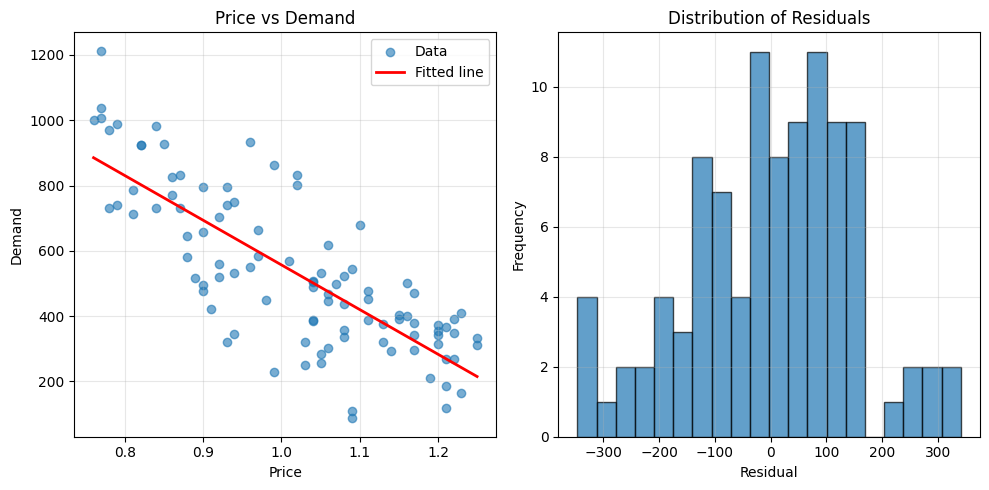

In [2]:
# Load the price/demand data (relative path: notebook lives in code/, data in data/)
df = pd.read_csv('../data/price_demand_data.csv')
print(f"Data shape: {df.shape}")
print(df.head())

# Fit Demand = beta_0 + beta_1 * Price + epsilon
X = df[['price']].values
y = df['demand'].values
reg = LinearRegression().fit(X, y)

beta_0 = reg.intercept_     # intercept
beta_1 = reg.coef_[0]       # slope (coefficient on price)
residuals = y - reg.predict(X)   # epsilon_i = D_i - (beta_0 + beta_1 * p_i)

print(f"\nbeta_0 (intercept): {beta_0:.4f}")
print(f"beta_1 (slope):     {beta_1:.4f}")
print(f"Demand = {beta_0:.4f} + ({beta_1:.4f}) * Price")
print(f"\nResiduals -> mean: {residuals.mean():.6f}, std: {residuals.std():.4f}, "
      f"range: [{residuals.min():.2f}, {residuals.max():.2f}]")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(df['price'], df['demand'], alpha=0.6, label='Data')
grid = np.linspace(df['price'].min(), df['price'].max(), 100)
axes[0].plot(grid, beta_0 + beta_1 * grid, 'r-', lw=2, label='Fitted line')
axes[0].set(xlabel='Price', ylabel='Demand', title='Price vs Demand')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[1].set(xlabel='Residual', ylabel='Frequency', title='Distribution of Residuals')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Part 2: Generate Demand Scenarios at p = 1

The residuals are the source of randomness. At a fixed price we get one demand
scenario per residual: `D_i(p) = beta_0 + beta_1 * p + epsilon_i`.

Base demand (beta_0 + beta_1*p): 557.0050
Mean: 557.0050, Std: 149.4520, Range: [210.09, 898.43]


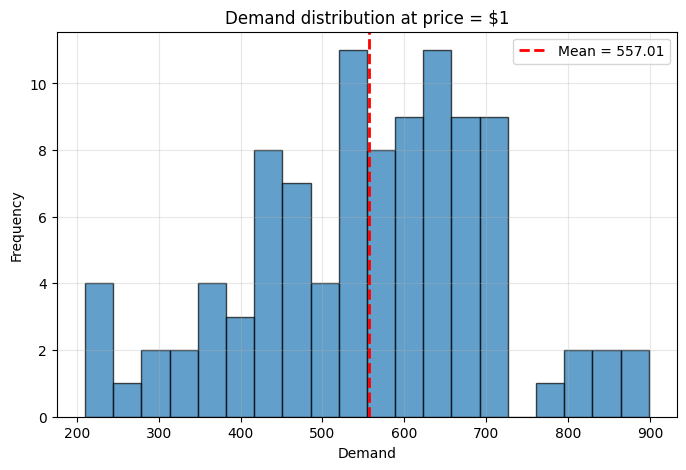

In [3]:
p = 1.0
demand_at_p1 = beta_0 + beta_1 * p + residuals
n = len(demand_at_p1)

print(f"Base demand (beta_0 + beta_1*p): {beta_0 + beta_1*p:.4f}")
print(f"Mean: {demand_at_p1.mean():.4f}, Std: {demand_at_p1.std():.4f}, "
      f"Range: [{demand_at_p1.min():.2f}, {demand_at_p1.max():.2f}]")

plt.figure(figsize=(8, 5))
plt.hist(demand_at_p1, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(demand_at_p1.mean(), color='r', ls='--', lw=2,
            label=f'Mean = {demand_at_p1.mean():.2f}')
plt.xlabel('Demand'); plt.ylabel('Frequency')
plt.title('Demand distribution at price = $1'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Part 3: Optimal Quantity at p = 1 (Linear Program)

For quantity `q` and scenario `i`: `profit_i = p*D_i - c*q - g*(D_i-q)+ - t*(q-D_i)+`.
The two positive-part terms are linearized with shortage `s_i >= D_i - q` and excess
`e_i >= q - D_i` (both >= 0); their positive costs in a maximization force them tight.

Restricted license - for non-production use only - expires 2026-11-23


Optimal quantity q* : 471.8654
Expected profit     : $231.4837
Days short / over   : 71 / 27 of 99


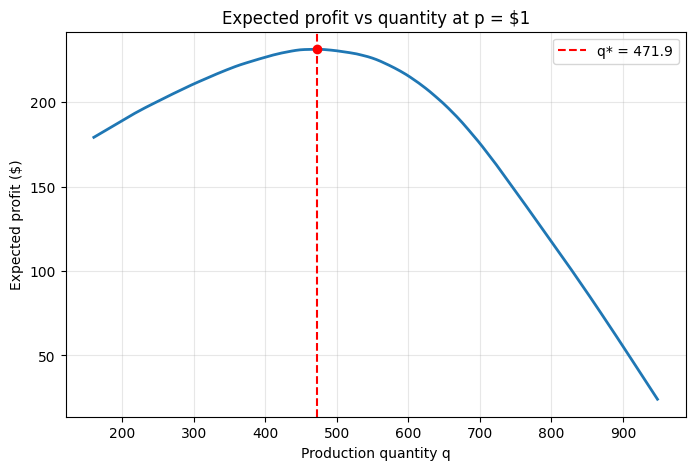

In [4]:
mod = gp.Model(); mod.Params.OutputFlag = 0
q = mod.addVar(lb=0.0, name='q')
s = mod.addMVar(n, lb=0.0, name='shortage')
e = mod.addMVar(n, lb=0.0, name='excess')
for i in range(n):
    mod.addConstr(s[i] >= demand_at_p1[i] - q)
    mod.addConstr(e[i] >= q - demand_at_p1[i])
mod.setObjective((1/n) * gp.quicksum(p*demand_at_p1[i] - c*q - g*s[i] - t*e[i]
                                     for i in range(n)), GRB.MAXIMIZE)
mod.optimize()

q3, profit3 = q.X, mod.ObjVal
print(f"Optimal quantity q* : {q3:.4f}")
print(f"Expected profit     : ${profit3:.4f}")
print(f"Days short / over   : {(s.X > 1e-3).sum()} / {(e.X > 1e-3).sum()} of {n}")

# Expected profit as a function of q, with the optimum marked
q_grid = np.linspace(demand_at_p1.min()-50, demand_at_p1.max()+50, 400)
curve = [np.mean(p*demand_at_p1 - c*qq - g*np.maximum(demand_at_p1-qq,0)
                 - t*np.maximum(qq-demand_at_p1,0)) for qq in q_grid]
plt.figure(figsize=(8,5))
plt.plot(q_grid, curve, lw=2)
plt.axvline(q3, color='r', ls='--', label=f'q* = {q3:.1f}')
plt.scatter([q3],[profit3], color='r', zorder=5)
plt.xlabel('Production quantity q'); plt.ylabel('Expected profit ($)')
plt.title('Expected profit vs quantity at p = $1'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Part 4: Joint Price–Quantity Optimization (Quadratic Program)

Price becomes a decision variable and demand depends on it:
`D_i(p) = beta_0 + beta_1*p + epsilon_i`. Revenue `p*D_i(p)` contains `beta_1*p^2`;
since `beta_1 < 0` this is concave, so maximizing expected profit is a convex QP that
Gurobi solves directly. Price is bounded to the observed range to avoid extrapolation.

In [5]:
def solve_joint_qp(b0, b1, eps, p_min, p_max):
    m = gp.Model(); m.Params.OutputFlag = 0
    nn = len(eps)
    p_var = m.addVar(lb=p_min, ub=p_max, name='price')
    q_var = m.addVar(lb=0.0, name='quantity')
    s = m.addMVar(nn, lb=0.0); e = m.addMVar(nn, lb=0.0)
    profit = 0
    for i in range(nn):
        D_i = b0 + b1*p_var + eps[i]
        m.addConstr(s[i] >= D_i - q_var)
        m.addConstr(e[i] >= q_var - D_i)
        profit += p_var*D_i - c*q_var - g*s[i] - t*e[i]
    m.setObjective(profit/nn, GRB.MAXIMIZE)
    m.optimize()
    return p_var.X, q_var.X, m.ObjVal

p_lo, p_hi = df['price'].min(), df['price'].max()
p4, q4, profit4 = solve_joint_qp(beta_0, beta_1, residuals, p_lo, p_hi)
print(f"Optimal price p*    : {p4:.4f}")
print(f"Optimal quantity q* : {q4:.4f}")
print(f"Expected profit     : ${profit4:.4f}")

Optimal price p*    : 0.9536
Optimal quantity q* : 535.2910
Expected profit     : $234.4249


## Part 6: Single Bootstrap Resample

Resample the data with replacement, refit the regression, and re-solve Part 4 to see
how sensitive the optimum is to the data.

In [6]:
def fit_and_solve_bootstrap():
    idx = np.random.choice(len(df), size=len(df), replace=True)
    Xb = df['price'].values[idx].reshape(-1, 1)
    yb = df['demand'].values[idx]
    rb = LinearRegression().fit(Xb, yb)
    eps_b = yb - rb.predict(Xb)
    return rb.intercept_, rb.coef_[0], *solve_joint_qp(rb.intercept_, rb.coef_[0],
                                                       eps_b, p_lo, p_hi)

np.random.seed(42)
b0_b, b1_b, p_b, q_b, profit_b = fit_and_solve_bootstrap()
print(f"beta_0 (boot): {b0_b:.4f}, beta_1 (boot): {b1_b:.4f}")
print(f"p* (boot): {p_b:.4f}, q* (boot): {q_b:.4f}, profit (boot): ${profit_b:.4f}")

beta_0 (boot): 1874.9307, beta_1 (boot): -1305.0360
p* (boot): 0.9683, q* (boot): 503.7146, profit (boot): $247.0996


## Part 7: Many Bootstraps — Distributions of p*, q*, Profit

In [7]:
B = 500
np.random.seed(123)
opt_prices, opt_quantities, opt_profits = [], [], []
for _ in range(B):
    _, _, pb, qb, prb = fit_and_solve_bootstrap()
    opt_prices.append(pb); opt_quantities.append(qb); opt_profits.append(prb)
opt_prices = np.array(opt_prices)
opt_quantities = np.array(opt_quantities)
opt_profits = np.array(opt_profits)

print(f"Price   : mean={opt_prices.mean():.4f}  std={opt_prices.std(ddof=1):.4f}")
print(f"Quantity: mean={opt_quantities.mean():.4f}  std={opt_quantities.std(ddof=1):.4f}")
print(f"Profit  : mean=${opt_profits.mean():.4f}  std=${opt_profits.std(ddof=1):.4f}")

Price   : mean=0.9549  std=0.0140
Quantity: mean=535.4729  std=34.9378
Profit  : mean=$234.8586  std=$9.0047


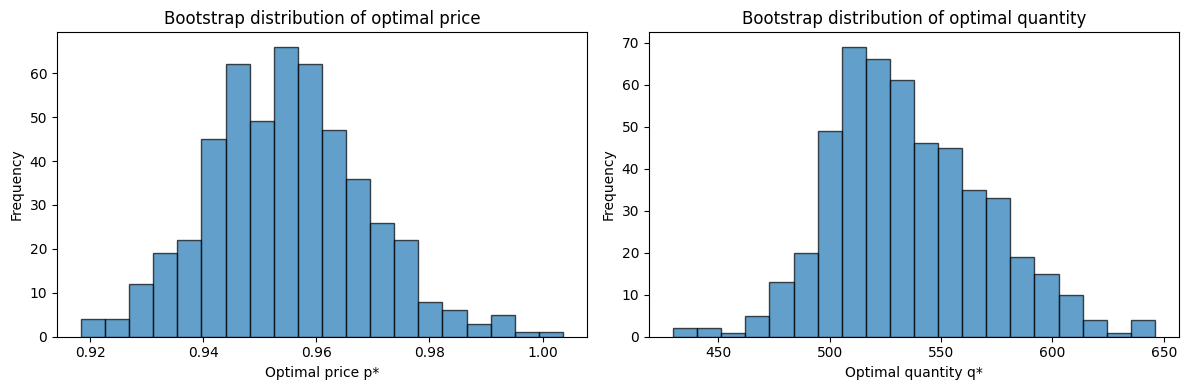

In [8]:
# Marginal histograms of optimal price and quantity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(opt_prices, bins=20, edgecolor='black', alpha=0.7)
axes[0].set(xlabel='Optimal price p*', ylabel='Frequency',
            title='Bootstrap distribution of optimal price')
axes[1].hist(opt_quantities, bins=20, edgecolor='black', alpha=0.7)
axes[1].set(xlabel='Optimal quantity q*', ylabel='Frequency',
            title='Bootstrap distribution of optimal quantity')
plt.tight_layout(); plt.show()

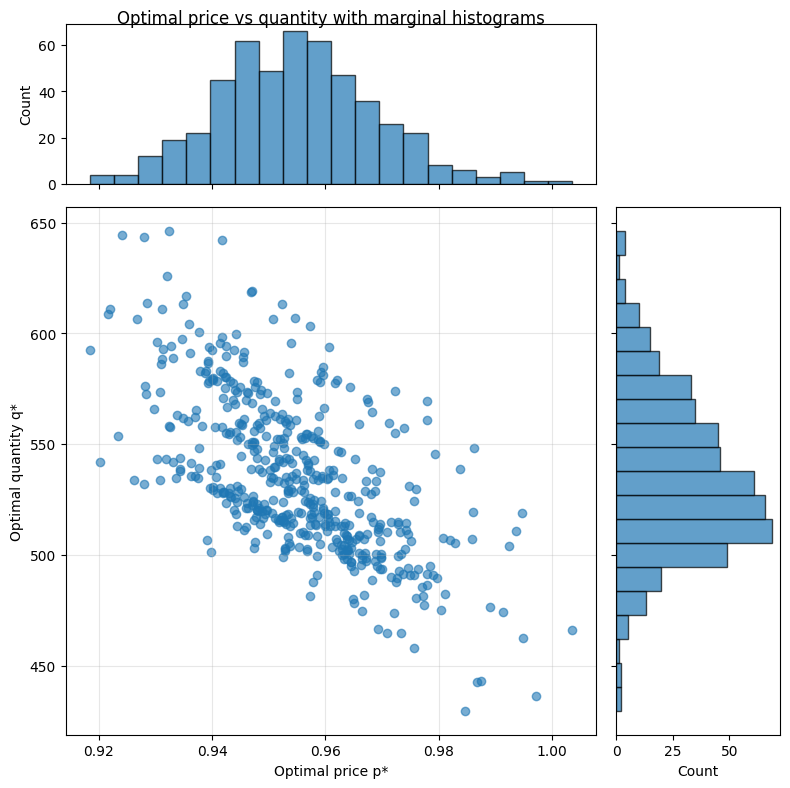

In [9]:
# Joint scatter with marginal histograms
fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(4, 4)
ax_sc = fig.add_subplot(gs[1:4, 0:3])
ax_hx = fig.add_subplot(gs[0, 0:3], sharex=ax_sc)
ax_hy = fig.add_subplot(gs[1:4, 3], sharey=ax_sc)
ax_sc.scatter(opt_prices, opt_quantities, alpha=0.6)
ax_sc.set(xlabel='Optimal price p*', ylabel='Optimal quantity q*'); ax_sc.grid(alpha=0.3)
ax_hx.hist(opt_prices, bins=20, edgecolor='black', alpha=0.7); ax_hx.set_ylabel('Count')
plt.setp(ax_hx.get_xticklabels(), visible=False)
ax_hy.hist(opt_quantities, bins=20, orientation='horizontal', edgecolor='black', alpha=0.7)
ax_hy.set_xlabel('Count'); plt.setp(ax_hy.get_yticklabels(), visible=False)
ax_hx.set_title('Optimal price vs quantity with marginal histograms', y=0.95)
plt.tight_layout(); plt.show()

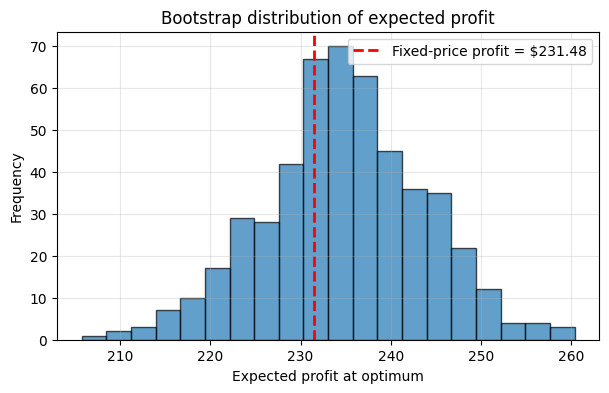

In [10]:
# Histogram of expected profit, with the fixed-price benchmark
plt.figure(figsize=(7, 4))
plt.hist(opt_profits, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(profit3, color='r', ls='--', lw=2, label=f'Fixed-price profit = ${profit3:.2f}')
plt.xlabel('Expected profit at optimum'); plt.ylabel('Frequency')
plt.title('Bootstrap distribution of expected profit'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Part 8: Is the Boss's Standard Newsvendor Model as Good as Ours?

The boss uses the **standard** newsvendor model: a fixed price (`p=1`), lost sales (no
rush orders), and no separate disposal cost. He chooses only `q`:
`max_q (1/n) * sum_i [ p*min(q, D_i) - c*q ]`.

We solve for the boss's quantity, then evaluate **every** decision on the same
real-world metric — the rush + disposal cost structure the firm actually faces. That is
the only fair way to ask whether switching models would raise profit.

In [11]:
def solve_standard_nvm(D, price):
    """Boss's model: fixed price, lost sales, choose q only."""
    m = gp.Model(); m.Params.OutputFlag = 0
    nn = len(D)
    q = m.addVar(lb=0.0)
    h = m.addMVar(nn, lb=-GRB.INFINITY)   # per-day profit
    for i in range(nn):
        m.addConstr(h[i] <= price*D[i] - c*q)   # demand-limited
        m.addConstr(h[i] <= price*q   - c*q)    # supply-limited
    m.setObjective((1/nn) * gp.quicksum(h[i] for i in range(nn)), GRB.MAXIMIZE)
    m.optimize()
    return q.X, m.ObjVal

def true_profit(price, q, b0=beta_0, b1=beta_1, eps=residuals):
    """Realized expected profit under the firm's true rush + disposal costs."""
    D = b0 + b1*price + eps
    return float(np.mean(price*D - c*q - g*np.maximum(D-q,0) - t*np.maximum(q-D,0)))

def lostsales_profit(price, q, b0=beta_0, b1=beta_1, eps=residuals):
    """Profit under the boss's own lost-sales accounting, for context."""
    D = b0 + b1*price + eps
    return float(np.mean(price*np.minimum(q, D) - c*q))

q_boss, _ = solve_standard_nvm(demand_at_p1, p)
boss_true       = true_profit(p,  q_boss)   # boss: standard NVM, p=1
fixedmodel_true = true_profit(p,  q3)        # right cost model, still p=1
ours_true       = true_profit(p4, q4)        # our joint price-quantity model

print(f"Boss's quantity (standard NVM, p=1): {q_boss:.4f}\n")
print("Expected profit under the TRUE (rush + disposal) cost structure:")
print(f"  Boss  (standard NVM, p=1, q={q_boss:6.1f}) : ${boss_true:.4f}")
print(f"  Right cost model, fixed p=1 (q={q3:6.1f}) : ${fixedmodel_true:.4f}")
print(f"  Our joint model  (p={p4:.3f}, q={q4:6.1f}) : ${ours_true:.4f}\n")
print("Decomposition of our gain over the boss:")
print(f"  Value of modeling the true cost structure : ${fixedmodel_true-boss_true:+.4f}")
print(f"  Value of optimizing price                 : ${ours_true-fixedmodel_true:+.4f}")
print(f"  Total gain over the boss                  : ${ours_true-boss_true:+.4f} "
      f"({100*(ours_true-boss_true)/boss_true:+.1f}%)\n")
print("Honest caveat - under the boss's OWN lost-sales accounting:")
print(f"  Boss (p=1,    q={q_boss:6.1f}) : ${lostsales_profit(p, q_boss):.4f}")
print(f"  Ours (p={p4:.3f}, q={q4:6.1f}) : ${lostsales_profit(p4, q4):.4f}")
print("  -> If rush/disposal costs were not real, the boss's quantity would be fine.")

Boss's quantity (standard NVM, p=1): 569.8968

Expected profit under the TRUE (rush + disposal) cost structure:
  Boss  (standard NVM, p=1, q= 569.9) : $222.6268
  Right cost model, fixed p=1 (q= 471.9) : $231.4837
  Our joint model  (p=0.954, q= 535.3) : $234.4249

Decomposition of our gain over the boss:
  Value of modeling the true cost structure : $+8.8569
  Value of optimizing price                 : $+2.9413
  Total gain over the boss                  : $+11.7982 (+5.3%)

Honest caveat - under the boss's OWN lost-sales accounting:
  Boss (p=1,    q= 569.9) : $219.2832
  Ours (p=0.954, q= 535.3) : $215.5549
  -> If rush/disposal costs were not real, the boss's quantity would be fine.


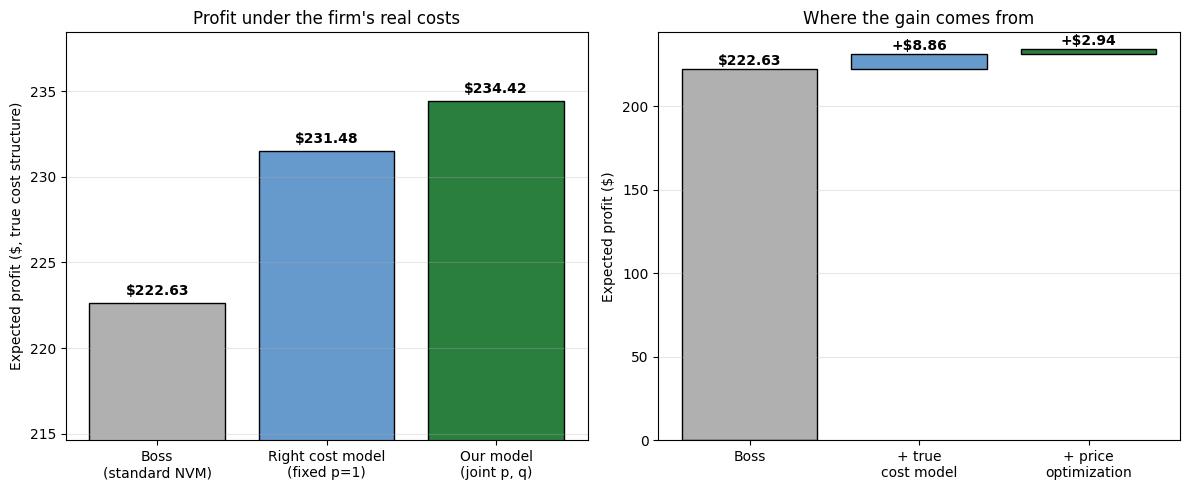

In [12]:
# Compare the three decisions on the true metric, and decompose the gain
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Boss\n(standard NVM)', 'Right cost model\n(fixed p=1)', 'Our model\n(joint p, q)']
vals = [boss_true, fixedmodel_true, ours_true]
colors = ['#b0b0b0', '#6699cc', '#2a7f3f']
bars = axes[0].bar(labels, vals, color=colors, edgecolor='black')
axes[0].set(ylabel='Expected profit ($, true cost structure)',
            title="Profit under the firm's real costs")
axes[0].set_ylim(min(vals)-8, max(vals)+4)
for b, v in zip(bars, vals):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.3, f'${v:.2f}',
                 ha='center', va='bottom', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

steps = ['Boss', '+ true\ncost model', '+ price\noptimization']
deltas = [boss_true, fixedmodel_true-boss_true, ours_true-fixedmodel_true]
cum = np.cumsum([0] + deltas[:-1])
axes[1].bar(steps, deltas, bottom=cum, color=colors, edgecolor='black')
axes[1].set(ylabel='Expected profit ($)', title='Where the gain comes from')
axes[1].set_ylim(0, max(vals)+10)
for st, d, base in zip(steps, deltas, cum):
    axes[1].text(st, base+d+0.5, (f'${d:.2f}' if st=='Boss' else f'+${d:.2f}'),
                 ha='center', va='bottom', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()